Downloading some libraries.

In [1]:
# Scikit-Learn ≥0.20 is required
import sklearn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# importing test metrics 
from sklearn.metrics import mean_squared_error, r2_score

# importing a splitter for the data 
from sklearn.model_selection import train_test_split

# Scaling the data 
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.linear_model import SGDRegressor

from sklearn.model_selection import learning_curve

# polynomial regression 
from sklearn.preprocessing import PolynomialFeatures



from sklearn.metrics import mean_squared_error, make_scorer


from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline



from sklearn.ensemble import RandomForestRegressor

from sklearn.pipeline import make_pipeline

from sklearn.ensemble import VotingRegressor

Reading the csv file using pandas, saving the data as a dataframe, and removing outlier values from the dataset to improve the performance of the models. 
Exploring the dataset. 

In [ ]:
def look_at_data_plots(df):
    # looking at the distribution of the columns 
    for columns in df:
        sns.kdeplot(df[columns], shade=True, color='red')
        plt.show()
        df[columns].hist()
        plt.show()

def show_correlations(df):
    plt.figure(figsize=(10, 8), dpi = 600)
    sns.heatmap(df.corr(), annot=True, cmap='cividis', fmt=".2f")
    plt.title("Correlation for the data")
    plt.show()


def show_outliers(df):
    # Detecting potential outliers using the IQR method
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
    print("Potential Outliers per Feature:")
    print(outliers)


# reading the csv file 
df = pd.read_csv("C:/Users/andsa/Documents/ML/concrete_data.csv")  


# looking for and removing potential null values 
ammount_of_null = int(df.isnull().sum().sum())
if ammount_of_null > 0:
    print(f'The ammount of null values in the dataset - {ammount_of_null} ')
    df.dropna(inplace=True)
    print("Null values removed")

# looking for and removing potential duplicates 
ammount_of_duplicates = df.duplicated().sum()
if ammount_of_duplicates > 0:
    print(f'The ammount of duplicate values in the dataset - {ammount_of_duplicates} ')
    df.drop_duplicates(inplace=True)
    print("Duplicates removed")

# remove outliers based on quantiles, and replace them with the mean value of the column data 
for column in df.columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

 
    df.loc[(df[column] < lower_bound) | (df[column] > upper_bound), column] = df[column].mean()


show_correlations(df)
# df.info()


TypeError: cannot convert the series to <class 'int'>

Assigning columns to the input and output variables X and y.

In [3]:
# assigning the X and y values 
X = df.drop(['Strength'], axis = 1)
y = df[['Strength']]

def show_X_and_y(X, y):
    X.info()
    y.info()

Importing libraries to split the data into a training and a test set, with 80 percent of the data used for training, and 20 percent used for testing. Also scaling the data, wich is important for all but the simple OLS. 

In [1]:
# importing test metrics 
from sklearn.metrics import mean_squared_error, r2_score

# importing a splitter for the data 
from sklearn.model_selection import train_test_split

# Splitting into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = pd.qcut(y, q = 5, duplicates='drop'))




# Scaling the data 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#introduce noise to the X_test data, for testing the limmits of the model, takes in the data and a percent e.g. 0.10
def noise_maker(X_test, scaling):
    return X_test * (1 + scaling)

X_test_noise = noise_maker(X_test, 0.10)

NameError: name 'X' is not defined

Creating and fitting a linear OLS and SGD model to the training data, to compare results. 

In [55]:
# Doing an ordinary least squares regression -> OLS 
from sklearn.linear_model import LinearRegression
lin_reg_OLS = LinearRegression()
# fitting the OLS model to the training data
lin_reg_OLS.fit(X_train, y_train)


# Doing a stochastic gradient descent method -> SGD, with max interations of 1000, eta of .01, and a constant learning rate 
from sklearn.linear_model import SGDRegressor
lin_reg_SGD = SGDRegressor(max_iter=1000, eta0=0.01, learning_rate="constant")
# fitting the SGD model to the training data 
lin_reg_SGD.fit(X_train_scaled, y_train)

c:\Users\andsa\anaconda3\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SGDRegressor(learning_rate='constant')

Predicting strength values with both models, and printing metrics to gauge performance. 

OLS Regression:
R² Score: 0.6185
MSE: 98.44

SGD Regression:
R² Score: 0.61
MSE: 100.82



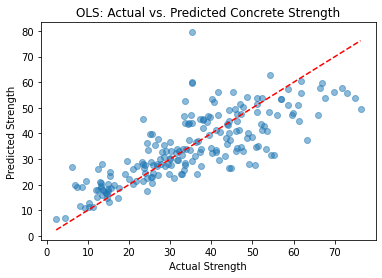

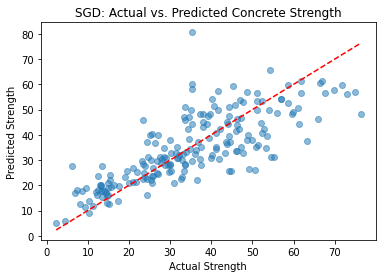

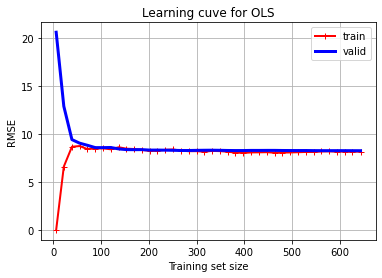

Underfitting - the model is too simple, more data won't help


In [56]:
# Predicting strength values on the testing set for both models.  
y_pred_OLS = lin_reg_OLS.predict(X_test)
y_pred_SGD = lin_reg_SGD.predict(X_test_scaled)


# printing the metrics for the OLS model 
print("OLS Regression:")
print(f"R² Score: {np.round(r2_score(y_test, y_pred_OLS), 4)}")
print(f"MSE: {np.round(mean_squared_error(y_test, y_pred_OLS), 2)}\n")


# printing the metrics for the SGD model 
print("SGD Regression:")
print(f"R² Score: {np.round(r2_score(y_test, y_pred_SGD), 2)}")
print(f"MSE: {np.round(mean_squared_error(y_test, y_pred_SGD), 2)}\n")

plt.scatter(y_test, y_pred_OLS, alpha=.5)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("OLS: Actual vs. Predicted Concrete Strength")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.show()


plt.scatter(y_test, y_pred_SGD, alpha=.5)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("SGD: Actual vs. Predicted Concrete Strength")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.show()




from sklearn.model_selection import learning_curve
train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(), X_train, y_train, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")


plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.title("Learning cuve for OLS")
plt.grid()
plt.legend(loc="upper right")
plt.show()
print("Underfitting - the model is too simple, more data won't help")

Creating a polynomial regressor to try to better fit the training data.

Simple polynomial Regression:
R² Score: 0.7187
MSE: 72.61



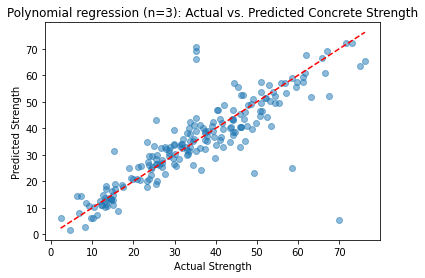

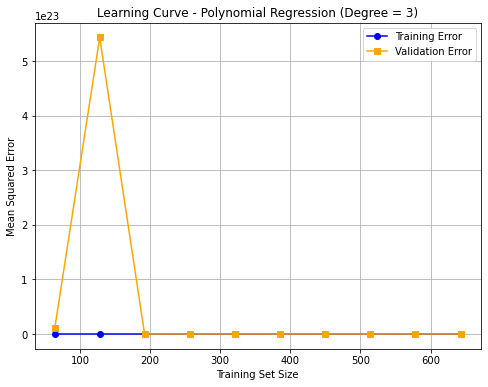

In [57]:
# polynomial regression 
from sklearn.preprocessing import PolynomialFeatures


poly_features = PolynomialFeatures(degree = 3, include_bias=False)
X_poly_train = poly_features.fit_transform(X_train_scaled)
X_poly_test = poly_features.transform(X_test_scaled)


lin_reg_for_poly = LinearRegression()
lin_reg_for_poly.fit(X_poly_train, y_train)

y_pred_poly = lin_reg_for_poly.predict(X_poly_test)

print("Simple polynomial Regression:")
print(f"R² Score: {np.round(r2_score(y_test, y_pred_poly), 4)}")
print(f"MSE: {np.round(mean_squared_error(y_test, y_pred_poly), 2)}\n")


plt.scatter(y_test, y_pred_poly, alpha=.5)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Polynomial regression (n=3): Actual vs. Predicted Concrete Strength")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.show()


import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Compute learning curve using your polynomial regression setup
train_sizes, train_scores, val_scores = learning_curve(
    lin_reg_for_poly, X_poly_train, y_train, cv=5, scoring=make_scorer(mean_squared_error),
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

# Compute mean errors
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', label="Training Error", color='blue')
plt.plot(train_sizes, val_mean, 's-', label="Validation Error", color='orange')
plt.xlabel("Training Set Size")
plt.ylabel("Mean Squared Error")
plt.title("Learning Curve - Polynomial Regression (Degree = 3)")
plt.legend()
plt.grid()
plt.show()

Trying out a polynomial Lasso regression with hyperparameter tuning, going through multiple different degrees. 

c:\Users\andsa\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.785e+01, tolerance: 1.599e+01
  model = cd_fast.enet_coordinate_descent(
c:\Users\andsa\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.305e+01, tolerance: 1.574e+01
  model = cd_fast.enet_coordinate_descent(
c:\Users\andsa\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.591e+02, toleranc

Best Parameters: {'poly__degree': 5, 'regressor__alpha': 0.1, 'regressor__fit_intercept': True}
R² Score: 0.7792
MSE: 56.9781


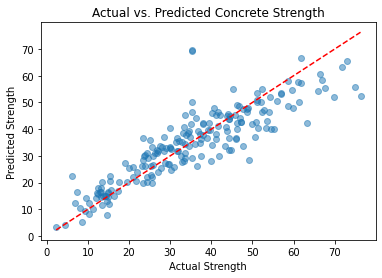

In [58]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Create a pipeline with PolynomialFeatures, StandardScaler, and Lasso regression
pipeline = Pipeline([
    ('poly', PolynomialFeatures()),    # Polynomial features
    ('scaler', StandardScaler()),      # Scaling the features
    ('regressor', Lasso())             # Lasso regression
])

# Define the parameter grid for GridSearchCV
param_grid = {
    'poly__degree': [1, 2, 3, 4, 5],       # Degrees of the polynomial
    'regressor__alpha': [0.1, 0.5, 1.0, 10],  # Regularization strength for Lasso
    'regressor__fit_intercept': [True, False]  # Whether or not to fit the intercept term
}

# Perform Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the model using the grid search
grid_search.fit(X_train, y_train)

# Get the best parameters from the grid search
best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

# Predict using the best model
y_pred_lasso_grid = grid_search.predict(X_test)

# Evaluate the model
print(f"R² Score: {np.round(r2_score(y_test, y_pred_lasso_grid), 4)}")
print(f"MSE: {np.round(mean_squared_error(y_test, y_pred_lasso_grid), 4)}")


plt.scatter(y_test, y_pred_lasso_grid, alpha=.5)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs. Predicted Concrete Strength")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.show()

R2 Score : 0.6185420722412007
Mean Squared Error : 98.44477635545634
Root Mean Squared Error : 9.921934103563496


c:\Users\andsa\anaconda3\lib\site-packages\sklearn\base.py:1152: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


R2 Score : 0.8762319326115373
Mean Squared Error : 31.941451015558822
Root Mean Squared Error : 5.6516768321940365


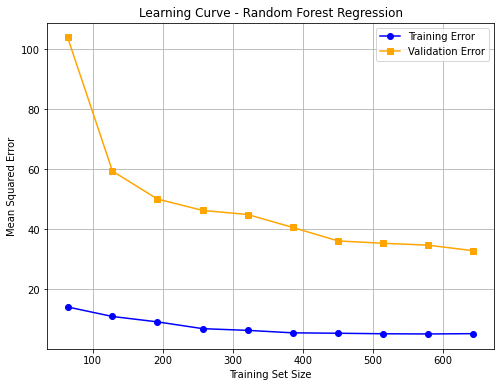

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
def model_train(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("R2 Score :", r2_score(y_test, y_pred))
    print("Mean Squared Error :", mean_squared_error(y_test, y_pred))
    print("Root Mean Squared Error :", mean_squared_error(y_test, y_pred)**0.5)

from sklearn.linear_model import LinearRegression
model_train(LinearRegression(), X_train, X_test, y_train, y_test)

from sklearn.ensemble import RandomForestRegressor
model_train(RandomForestRegressor(), X_train, X_test, y_train, y_test)



import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import learning_curve, train_test_split
from sklearn.metrics import mean_squared_error, make_scorer


# Compute learning curve
train_sizes, train_scores, val_scores = learning_curve(
    RandomForestRegressor(), X_train, y_train, cv=5, scoring=make_scorer(mean_squared_error),
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

# Compute mean errors
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', label="Training Error", color='blue')
plt.plot(train_sizes, val_mean, 's-', label="Validation Error", color='orange')
plt.xlabel("Training Set Size")
plt.ylabel("Mean Squared Error")
plt.title("Learning Curve - Random Forest Regression")
plt.legend()
plt.grid()
plt.show()

Create a story
Maybe test with noisey data, 
retrain, more training

test with dropping data 

R² Score: 0.8136
MSE: 48.1148


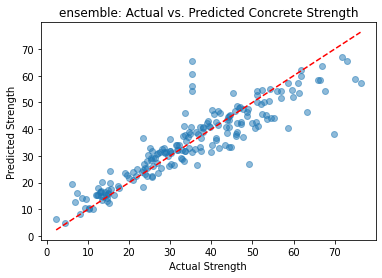

In [ ]:
from sklearn.ensemble import VotingRegressor


# Define individual models
poly_model = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
lasso_model = Lasso(alpha=0.1)

# Create the voting ensemble
ensemble = VotingRegressor(estimators=[
    ('poly', poly_model),
    ('rf', rf_model),
    ('lasso', lasso_model)
])


# Train the ensemble model
# ensemble.fit(X_train, y_train.to_numpy().ravel())
ensemble.fit(X_train, y_train.squeeze())

# Predict on the test set
y_pred_ensemble = ensemble.predict(X_test)


# Evaluate the model
print(f"R² Score: {np.round(r2_score(y_test, y_pred_ensemble), 4)}")
print(f"MSE: {np.round(mean_squared_error(y_test, y_pred_ensemble), 4)}")


plt.scatter(y_test, y_pred_ensemble, alpha=.5)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("ensemble: Actual vs. Predicted Concrete Strength")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.show()




Imagine yourself as a researcher or maybe at the construction site. Yout task is to create a mixture for a concrete sample that you are testing, and based on your ingredients you would like to have a prediction for the strengh of the finnished product. By using the models that have been trained, you are able to get an idea of the capabilities of the finnished product, potentially saving you time and making you workflow more efficient. 

As the models that got the best results (RandomForestRegressor) show signs of overfitting, either reducing, or more likely getting more data to train the models on would be benefitial. Both for keeping the model in good shape, preventing rot, but also to get more accurate estimates from the model. Therefore we would urge the users of the models to share their mixtures and strength results. So that the model can keep evolving and improving. 